In [29]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import expon
import seaborn as sns


Comparing sigma to z table on wikipedia:
The sigma values I picked were 1, 2, and 3. The code below shows that the area from -inf to z=1 is 0.84134, and that the probabilities of 0.97725 and 0.99865 correspond to sigma values of 2 and 3 for the cumulative z table on the wikipedia page linked in the lab

In [57]:
# integral from -infinity to a given z-score. in this case 1. This should give 0.84134 according to the z-table on wikipedia
area_left = norm.cdf(1)
print(f"Area from -inf to 1: {area_left}")

# associated sigma value for a given probability using ppf
# 0.975 
sigma2 = norm.ppf(0.97725)
sigma3 = norm.ppf(0.99865)
print(f"Sigma value for 0.97725: {sigma2}")
print(f"Sigma value for 0.99865: {sigma3}")

Area from -inf to 1: 0.8413447460685429
Sigma value for 0.97725: 2.0000024438996027
Sigma value for 0.99865: 2.9999769927034015


Plotting an exponential distribution:

<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:21: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_302/2229381927.py:18: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_axis, analytic_pdf, color="darkblue", linewidth=2.5, label=f"Analytic PDF ($\lambda$ = {lam})")
/tmp/ipykernel_302/2229381927.py:21: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"Exponential Distribution ($\lambda$ = {lam}): Simulation vs. Theory")


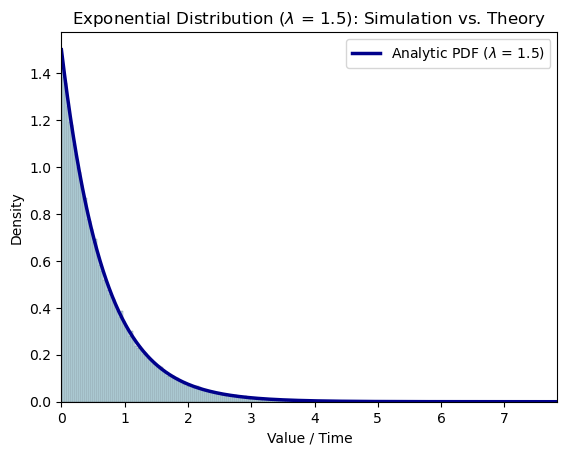

In [68]:
# Set the rate parameter (lambda) and calculate scale (beta = 1/lambda)
lam = 1.5
scale = 1 / lam  # Average time between events

# generate 100000 random samples from the distribution
data = np.random.exponential(scale=scale, size=100000)

# Plot both the histogram bars
sns.histplot(data, stat="density", color="lightblue")

# Generate smooth x-values for the analytic line
# We go from 0 to the maximum simulated value in the data
x_axis = np.linspace(0, np.max(data), 1000)

analytic_pdf = expon.pdf(x_axis, scale=scale)

# 4. Plot the analytic PDF line on top
plt.plot(x_axis, analytic_pdf, color="darkblue", linewidth=2.5, label=f"Analytic PDF ($\lambda$ = {lam})")

# add formatting details
plt.title(f"Exponential Distribution ($\lambda$ = {lam}): Simulation vs. Theory")
plt.xlabel("Value / Time")
plt.ylabel("Density")
plt.xlim(0, np.max(data))  
plt.legend()                
plt.show()

Value chosen for my hypothetical measurement: 2.2
What is the probability that another measurement taken will take a value less than or equal to this measurement of 2.2?

In [49]:
prob = expon.cdf(2.2, loc=0, scale=scale)
print(f"Probability: {prob}")

# Calculate PPF for probabilities [0.1, 0.5, 0.99] with default loc=0, scale=1
vals = expon.ppf([0.1, 0.5, 0.99])
print(vals)

Probability: 0.96311683259876
[0.10536052 0.69314718 4.60517019]


$$P(X \le 2.2) = \int_{0}^{2.2} 1.5 e^{-1.5 x} \, dx = 1 - e^{-3.3}$$

The integral is equal to 0.96311, which matches the exponential cdf function earlier

In [66]:
import scipy.stats as stats

# define distribution parameters
lam = 1.5
scale = 1 / lam  # scipy uses 'scale', which is 1/lambda

# Observed measurement
x = 2.2

# Calculate the p-value (probability background produced this or worse)
p_value = 1 - stats.expon.cdf(x, scale=scale)

# Convert p-value to an equivalent one-sided normal 'sigma'
sigma = stats.norm.ppf(1 - p_value)

print(f"p-value: {p_value:.6f}")
print(f"Sigma: {sigma:.2f} sigma")


p-value: 0.036883
Sigma: 1.79 sigma


The probability that the background produced the signal is given above with the p-value. And the sigma is 1.79

In [67]:
prob = expon.cdf(0.5, loc=0, scale=scale)
print(f"Probability of 0.5 sigma: {prob}")
prob1 = expon.cdf(1, loc=0, scale=scale)
print(f"Probability of 1 sigma: {prob1}")
prob2 = expon.cdf(2, loc=0, scale=scale)
print(f"Probability of 2 sigma: {prob2}")

Probability of 0.5 sigma: 0.5276334472589853
Probability of 1 sigma: 0.7768698398515702
Probability of 2 sigma: 0.950212931632136


These different area values show how the exponential distribution tapers off. Compared to a normal distribution, the values for z = 0.5, 1, and 2, respectively would be 0.691, 0.841, and 0.977. The values for the exponential distribution given above are each lower than the normal distribution values. This makes sense since the exponential distribution is skewed to the right with a cutoff at 0 on the x-axis. This will lead to there being a larger proportion of points beyond 2 sigma than in the normal distribution.